# Модели машинного обучения
## ВКР: прогнозирование свойств композиционных материалов

Блок 2 выпускной квалификационной работы. Строим и сравниваем регрессионные
модели для прогнозирования двух целевых показателей:

- **Модуль упругости при растяжении, ГПа**
- **Прочность при растяжении, МПа**

Для каждого показателя строится отдельная модель (по заданию проекта — "один
показатель — одна модель").


In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid", font_scale=0.9)
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 100

FIGURES_DIR = "../figures"
DATA_DIR = "../data/processed"
MODELS_DIR = "../app/models"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)


## 1. Загрузка данных

Используем **очищенный, но ненормализованный** датасет
`data/processed/data_clean.csv` (после удаления выбросов методом IQR в
Блоке 1). Нормализация будет выполнена внутри `Pipeline` на этапе обучения
моделей (см. раздел 3), а не на этапе загрузки — это важно для корректной
оценки качества моделей.

In [2]:
df = pd.read_csv(os.path.join(DATA_DIR, "data_clean.csv"), index_col=0)
print("Размер датасета:", df.shape)
df.head()


Размер датасета: (936, 13)


,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
1,1.857143,2030.0,738.736842,50.00,23.750000,284.615385,210.0,70.0,3000.0,220.0,0,4.0,60.0
3,1.857143,2030.0,738.736842,129.00,21.250000,300.000000,210.0,70.0,3000.0,220.0,0,5.0,47.0
4,2.771331,2030.0,753.000000,111.86,22.267857,284.615385,210.0,70.0,3000.0,220.0,0,5.0,57.0
5,2.767918,2000.0,748.000000,111.86,22.267857,284.615385,210.0,70.0,3000.0,220.0,0,5.0,60.0
6,2.569620,1910.0,807.000000,111.86,22.267857,284.615385,210.0,70.0,3000.0,220.0,0,5.0,70.0


## 2. Формирование признаков и целевых переменных

В датасете 13 столбцов, из которых два являются целевыми показателями:

- «Модуль упругости при растяжении, ГПа»
- «Прочность при растяжении, МПа»

Для каждого из двух объектов моделирования матрица признаков `X` строится из
**11 оставшихся столбцов**, а **второй** целевой показатель в неё не
включается. Причины:

1. **Утечка данных (data leakage) и отсутствие практической применимости.**
   Оба показателя — «Модуль упругости при растяжении» и «Прочность при
   растяжении» — являются результатами одного и того же процесса испытаний
   образца, а не независимыми технологическими параметрами. На практике,
   когда модель применяется для прогноза (например, на этапе проектирования
   состава материала, ещё до изготовления и испытания образца), значения
   **обоих** целевых показателей заранее неизвестны. Если бы мы использовали
   один целевой показатель как признак для предсказания другого, модель была
   бы неприменима в реальных условиях эксплуатации.
2. **Корректность оценки качества модели.** Включение второго целевого
   показателя в число признаков может создать эффект "подсказки" — модель
   научится использовать связанные с испытаниями артефакты вместо реальных
   технологических параметров (состав, плотность, температура и т.д.), что
   исказит оценку её реальной прогностической способности.

Поэтому вход `X` для каждой задачи включает только *технологические и
физические параметры материала*, не связанные напрямую с результатами
механических испытаний на растяжение.

In [3]:
TARGET_MODULUS = "Модуль упругости при растяжении, ГПа"
TARGET_STRENGTH = "Прочность при растяжении, МПа"

TARGETS = {
    "modulus": TARGET_MODULUS,
    "strength": TARGET_STRENGTH,
}

feature_cols = [c for c in df.columns if c not in (TARGET_MODULUS, TARGET_STRENGTH)]
print(f"Количество признаков: {len(feature_cols)}")
for c in feature_cols:
    print(" -", c)


Количество признаков: 11
 - Соотношение матрица-наполнитель
 - Плотность, кг/м3
 - модуль упругости, ГПа
 - Количество отвердителя, м.%
 - Содержание эпоксидных групп,%_2
 - Температура вспышки, С_2
 - Поверхностная плотность, г/м2
 - Потребление смолы, г/м2
 - Угол нашивки, град
 - Шаг нашивки
 - Плотность нашивки


## 3. Разбиение на выборки и нормализация в Pipeline

Данные делим на обучающую и тестовую выборки: `train_test_split(test_size=0.3,
random_state=42)`.

Нормализацию (`MinMaxScaler`) выполняем **внутри `Pipeline`**, а не отдельным
шагом перед разбиением. Это принципиально важно: если бы `MinMaxScaler`
обучался (`fit`) на всём датасете до разбиения, минимум и максимум
рассчитывались бы с учётом тестовых данных — то есть информация о тестовой
выборке "просачивалась" бы в обучение (**утечка данных**). Внутри `Pipeline`
скейлер вызывает `fit` **только на обучающей части** каждого фолда
кросс-валидации и на всей обучающей выборке при финальном обучении, а к
тестовым/валидационным данным применяется только `transform` с уже
рассчитанными параметрами.

In [4]:
def make_split(target_col):
    X = df[feature_cols].copy()
    y = df[target_col].copy()
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=RANDOM_STATE
    )
    return X_train, X_test, y_train, y_test

splits = {name: make_split(col) for name, col in TARGETS.items()}

for name, (X_train, X_test, y_train, y_test) in splits.items():
    print(f"{name}: X_train={X_train.shape}, X_test={X_test.shape}")


modulus: X_train=(655, 11), X_test=(281, 11)
strength: X_train=(655, 11), X_test=(281, 11)


## 4. Модели и подбор гиперпараметров

Для каждого объекта прогнозирования обучаем 9 моделей, начиная с
`DummyRegressor` (базовая линия, предсказывающая среднее/медиану обучающей
выборки). Для каждой модели, включая `DummyRegressor`, выполняется
`GridSearchCV(cv=10, n_jobs=-1)` по умеренной сетке гиперпараметров —
сетки подобраны так, чтобы полный перебор занимал разумное время (единицы
минут) на датасете такого размера (~936 строк).

Каждая модель обёрнута в `Pipeline`: `MinMaxScaler` → модель, чтобы
масштабирование признаков выполнялось корректно (см. раздел 3).

In [5]:
MODEL_SPECS = {
    "DummyRegressor": (
        DummyRegressor(),
        {"model__strategy": ["mean", "median"]},
    ),
    "LinearRegression": (
        LinearRegression(),
        {"model__fit_intercept": [True, False]},
    ),
    "Ridge": (
        Ridge(random_state=RANDOM_STATE),
        {"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
    ),
    "Lasso": (
        Lasso(random_state=RANDOM_STATE, max_iter=10000),
        {"model__alpha": [0.001, 0.01, 0.1, 1.0, 10.0]},
    ),
    "KNeighborsRegressor": (
        KNeighborsRegressor(),
        {
            "model__n_neighbors": [3, 5, 7, 9, 11],
            "model__weights": ["uniform", "distance"],
        },
    ),
    "DecisionTreeRegressor": (
        DecisionTreeRegressor(random_state=RANDOM_STATE),
        {
            "model__max_depth": [3, 5, 7, 10, None],
            "model__min_samples_leaf": [1, 2, 5],
        },
    ),
    "RandomForestRegressor": (
        RandomForestRegressor(random_state=RANDOM_STATE),
        {
            "model__n_estimators": [100, 300],
            "model__max_depth": [None, 8],
            "model__min_samples_leaf": [1, 3],
        },
    ),
    "GradientBoostingRegressor": (
        GradientBoostingRegressor(random_state=RANDOM_STATE),
        {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [2, 3],
        },
    ),
    "SVR": (
        SVR(),
        {
            "model__C": [0.1, 1.0, 10.0],
            "model__kernel": ["linear", "rbf"],
        },
    ),
}

def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}


In [6]:
results = {}       # results[target_name][model_name] = dict(metrics + best_params)
fitted_models = {}  # fitted_models[target_name][model_name] = fitted GridSearchCV

for target_name, (X_train, X_test, y_train, y_test) in splits.items():
    print(f"\n=== Целевой показатель: {TARGETS[target_name]} ===")
    results[target_name] = {}
    fitted_models[target_name] = {}

    for model_name, (estimator, param_grid) in MODEL_SPECS.items():
        pipe = Pipeline([
            ("scaler", MinMaxScaler()),
            ("model", estimator),
        ])
        grid = GridSearchCV(
            pipe, param_grid=param_grid, cv=10,
            scoring="r2", n_jobs=-1,
        )
        grid.fit(X_train, y_train)

        y_train_pred = grid.predict(X_train)
        y_test_pred = grid.predict(X_test)

        train_metrics = regression_metrics(y_train, y_train_pred)
        test_metrics = regression_metrics(y_test, y_test_pred)

        results[target_name][model_name] = {
            "best_params": grid.best_params_,
            "train": train_metrics,
            "test": test_metrics,
        }
        fitted_models[target_name][model_name] = grid

        print(f"{model_name:28s} best_params={grid.best_params_}  R2_test={test_metrics['R2']:.4f}")



=== Целевой показатель: Модуль упругости при растяжении, ГПа ===


DummyRegressor               best_params={'model__strategy': 'mean'}  R2_test=-0.0059
LinearRegression             best_params={'model__fit_intercept': True}  R2_test=-0.0036
Ridge                        best_params={'model__alpha': 100.0}  R2_test=-0.0026


Lasso                        best_params={'model__alpha': 0.1}  R2_test=-0.0059


KNeighborsRegressor          best_params={'model__n_neighbors': 11, 'model__weights': 'uniform'}  R2_test=-0.0940


DecisionTreeRegressor        best_params={'model__max_depth': 3, 'model__min_samples_leaf': 1}  R2_test=-0.0237


...

DummyRegressor               best_params={'model__strategy': 'median'}  R2_test=-0.0351
LinearRegression             best_params={'model__fit_intercept': True}  R2_test=-0.0454
Ridge                        best_params={'model__alpha': 100.0}  R2_test=-0.0287


Lasso                        best_params={'model__alpha': 10.0}  R2_test=-0.0297
KNeighborsRegressor          best_params={'model__n_neighbors': 11, 'model__weights': 'distance'}  R2_test=-0.1533


DecisionTreeRegressor        best_params={'model__max_depth': 3, 'model__min_samples_leaf': 5}  R2_test=-0.0866


RandomForestRegressor        best_params={'model__max_depth': 8, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}  R2_test=-0.0542


GradientBoostingRegressor    best_params={'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 100}  R2_test=-0.0461
SVR                          best_params={'model__C': 0.1, 'model__kernel': 'rbf'}  R2_test=-0.0353


## 5. Таблицы метрик

Для каждого объекта собираем сводную таблицу MAE, MSE, RMSE и R² на
обучающей и тестовой выборках для всех моделей и сохраняем её в
`figures/metrics_modulus.csv` и `figures/metrics_strength.csv`.

In [7]:
def build_metrics_table(target_name):
    rows = []
    for model_name, res in results[target_name].items():
        rows.append({
            "Модель": model_name,
            "Лучшие гиперпараметры": json.dumps(res["best_params"], ensure_ascii=False),
            "MAE_train": res["train"]["MAE"],
            "MSE_train": res["train"]["MSE"],
            "RMSE_train": res["train"]["RMSE"],
            "R2_train": res["train"]["R2"],
            "MAE_test": res["test"]["MAE"],
            "MSE_test": res["test"]["MSE"],
            "RMSE_test": res["test"]["RMSE"],
            "R2_test": res["test"]["R2"],
        })
    table = pd.DataFrame(rows).sort_values("R2_test", ascending=False).reset_index(drop=True)
    return table

metrics_tables = {name: build_metrics_table(name) for name in TARGETS}

metrics_tables["modulus"].to_csv(os.path.join(FIGURES_DIR, "metrics_modulus.csv"), index=False, encoding="utf-8-sig")
metrics_tables["strength"].to_csv(os.path.join(FIGURES_DIR, "metrics_strength.csv"), index=False, encoding="utf-8-sig")

print("Метрики: Модуль упругости при растяжении, ГПа")
display(metrics_tables["modulus"])


Метрики: Модуль упругости при растяжении, ГПа


,Модель,Лучшие гиперпараметры,MAE_train,MSE_train,RMSE_train,R2_train,MAE_test,MSE_test,RMSE_test,R2_test
0,SVR,"{""model__C"": 0.1, ""model__kernel"": ""rbf""}",2.410437,9.134742,3.022374,0.029819,2.398508,8.700212,2.949612,0.001608
1,GradientBoostingRegressor,"{""model__learning_rate"": 0.05, ""model__max_dep...",2.254183,7.857645,2.803149,0.165456,2.377812,8.703288,2.950133,0.001255
2,Ridge,"{""model__alpha"": 100.0}",2.465376,9.365770,3.060355,0.005282,2.400335,8.736489,2.955755,-0.002555
3,LinearRegression,"{""model__fit_intercept"": true}",2.452521,9.277671,3.045927,0.014638,2.416002,8.745602,2.957296,-0.003601
4,DummyRegressor,"{""model__strategy"": ""mean""}",2.469857,9.415500,3.068469,0.000000,2.398634,8.765902,2.960727,-0.005930
5,Lasso,"{""model__alpha"": 0.1}",2.469857,9.415500,3.068469,0.000000,2.398634,8.765902,2.960727,-0.005930
6,RandomForestRegressor,"{""model__max_depth"": 8, ""model__min_samples_le...",1.732133,4.481847,2.117037,0.523993,2.416845,8.825295,2.970740,-0.012746
7,DecisionTreeRegressor,"{""model__max_depth"": 3, ""model__min_samples_le...",2.382794,8.935255,2.989190,0.051006,2.423656,8.920882,2.986785,-0.023715
8,KNeighborsRegressor,"{""model__n_neighbors"": 11, ""model__weights"": ""...",2.375917,8.799842,2.966453,0.065388,2.505728,9.533732,3.087674,-0.094042


In [8]:
print("Метрики: Прочность при растяжении, МПа")
display(metrics_tables["strength"])


Метрики: Прочность при растяжении, МПа


,Модель,Лучшие гиперпараметры,MAE_train,MSE_train,RMSE_train,R2_train,MAE_test,MSE_test,RMSE_test,R2_test
0,Ridge,"{""model__alpha"": 100.0}",371.224408,215966.968575,464.722464,0.008126,359.892987,209961.275325,458.215315,-0.028686
1,Lasso,"{""model__alpha"": 10.0}",372.430994,217736.229939,466.622149,0.000000,360.306251,210162.565630,458.434909,-0.029672
2,DummyRegressor,"{""model__strategy"": ""median""}",372.328500,217782.966907,466.672226,-0.000215,361.303740,211273.348220,459.644807,-0.035114
3,SVR,"{""model__C"": 0.1, ""model__kernel"": ""rbf""}",372.251935,217725.813759,466.610988,0.000048,361.342472,211304.553775,459.678751,-0.035267
4,LinearRegression,"{""model__fit_intercept"": true}",368.398722,212351.595204,460.816227,0.024730,362.854584,213381.584134,461.932445,-0.045443
5,GradientBoostingRegressor,"{""model__learning_rate"": 0.05, ""model__max_dep...",334.536261,174455.573882,417.678793,0.198776,365.761923,213518.059728,462.080144,-0.046112
6,RandomForestRegressor,"{""model__max_depth"": 8, ""model__min_samples_le...",251.575239,94157.937987,306.851655,0.567560,371.044029,215173.260183,463.867718,-0.054221
7,DecisionTreeRegressor,"{""model__max_depth"": 3, ""model__min_samples_le...",355.164868,197981.925463,444.951599,0.090726,376.594400,221786.417134,470.942053,-0.086622
8,KNeighborsRegressor,"{""model__n_neighbors"": 11, ""model__weights"": ""...",0.000000,0.000000,0.000000,1.000000,376.950322,235393.137172,485.173306,-0.153287


## 6. Графики

### 6.1 Сравнение R² на тестовой выборке по всем моделям

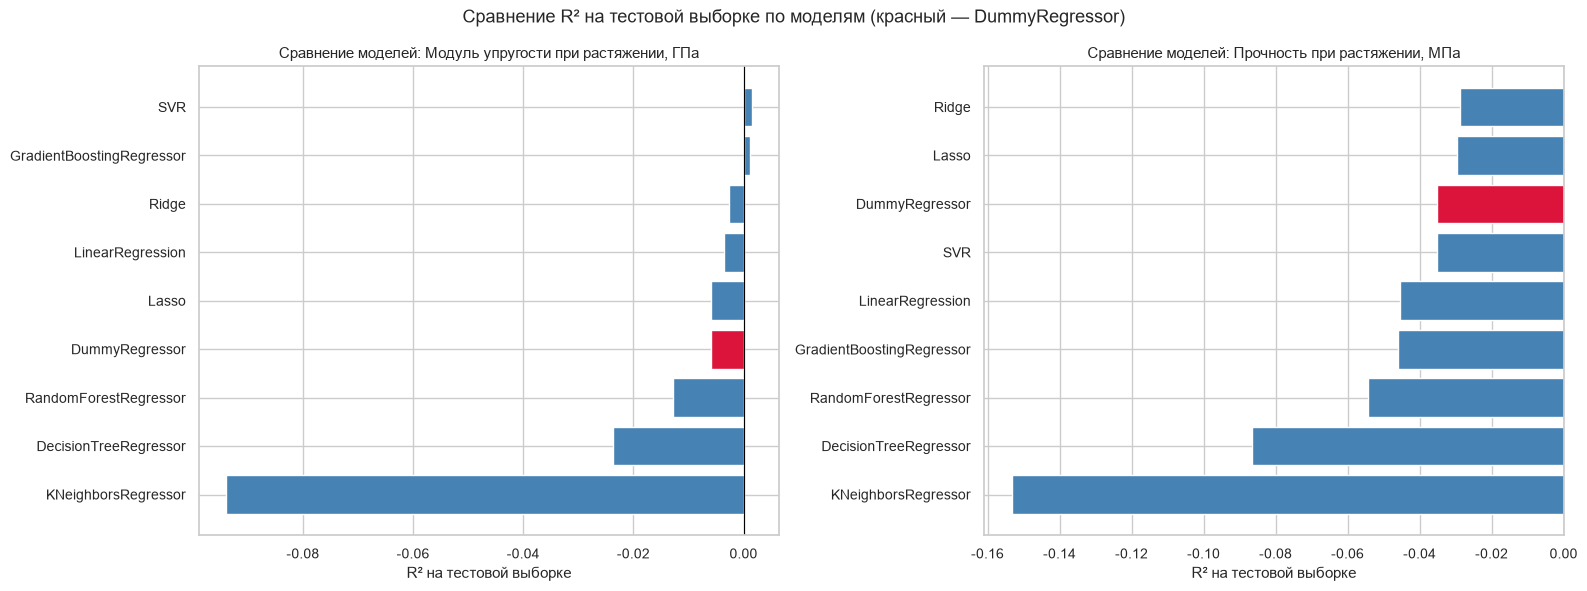

In [9]:
TARGET_LABELS = {
    "modulus": "Модуль упругости при растяжении, ГПа",
    "strength": "Прочность при растяжении, МПа",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, target_name in zip(axes, TARGETS):
    table = metrics_tables[target_name].sort_values("R2_test", ascending=True)
    colors = ["crimson" if m == "DummyRegressor" else "steelblue" for m in table["Модель"]]
    ax.barh(table["Модель"], table["R2_test"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("R² на тестовой выборке")
    ax.set_title(f"Сравнение моделей: {TARGET_LABELS[target_name]}", fontsize=11)

fig.suptitle("Сравнение R² на тестовой выборке по моделям (красный — DummyRegressor)", fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "r2_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()


### 6.2 Выбор лучшей модели для каждого показателя

Лучшей считается модель с максимальным R² на тестовой выборке, при условии,
что она содержательно превосходит `DummyRegressor` (иначе честно указываем,
что ни одна модель не дала практически значимого улучшения по сравнению с
базовой линией).

In [10]:
best_model_names = {}

for target_name in TARGETS:
    table = metrics_tables[target_name]
    dummy_r2 = table.loc[table["Модель"] == "DummyRegressor", "R2_test"].values[0]
    best_row = table.iloc[0]  # таблица уже отсортирована по убыванию R2_test
    best_model_names[target_name] = best_row["Модель"]

    print(f"--- {TARGET_LABELS[target_name]} ---")
    print(f"DummyRegressor R2_test = {dummy_r2:.4f}")
    print(f"Лучшая модель: {best_row['Модель']}, R2_test = {best_row['R2_test']:.4f}, "
          f"RMSE_test = {best_row['RMSE_test']:.4f}")
    print()


--- Модуль упругости при растяжении, ГПа ---
DummyRegressor R2_test = -0.0059
Лучшая модель: SVR, R2_test = 0.0016, RMSE_test = 2.9496

--- Прочность при растяжении, МПа ---
DummyRegressor R2_test = -0.0351
Лучшая модель: Ridge, R2_test = -0.0287, RMSE_test = 458.2153



### 6.3 Диаграмма рассеяния: предсказание vs. фактическое значение (лучшая модель)

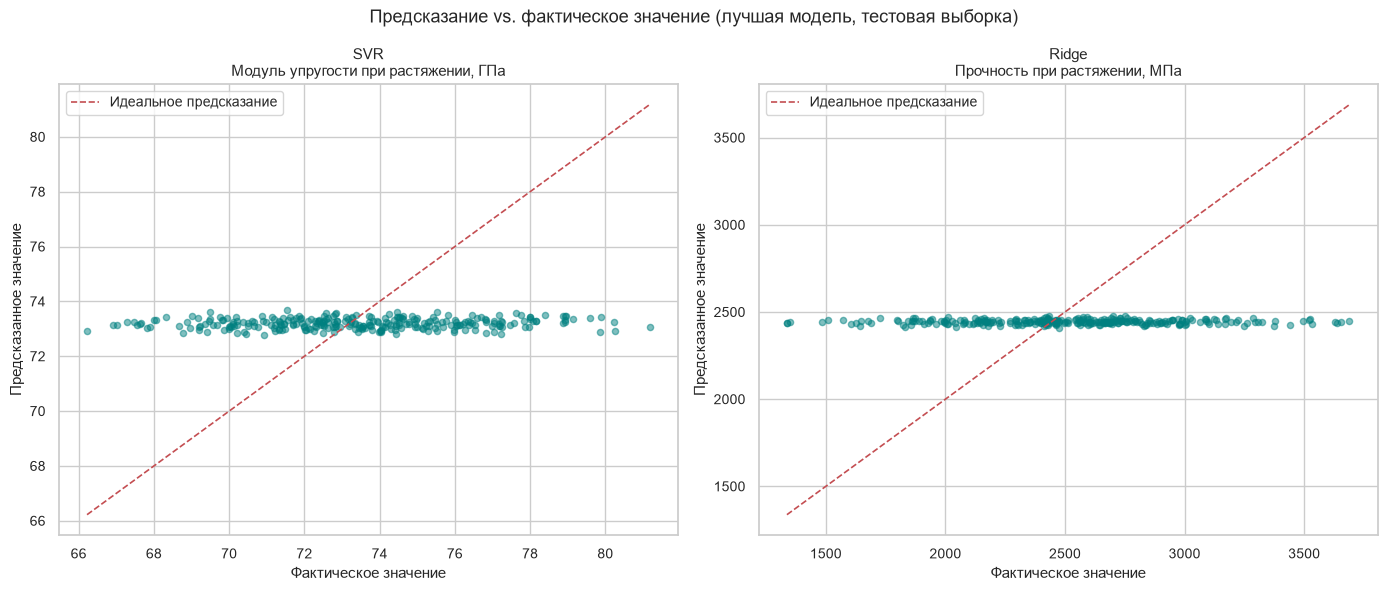

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, target_name in zip(axes, TARGETS):
    X_train, X_test, y_train, y_test = splits[target_name]
    best_name = best_model_names[target_name]
    best_grid = fitted_models[target_name][best_name]
    y_pred = best_grid.predict(X_test)

    ax.scatter(y_test, y_pred, alpha=0.5, s=20, color="teal")
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", linewidth=1.2, label="Идеальное предсказание")
    ax.set_xlabel("Фактическое значение")
    ax.set_ylabel("Предсказанное значение")
    ax.set_title(f"{best_name}\n{TARGET_LABELS[target_name]}", fontsize=11)
    ax.legend()

fig.suptitle("Предсказание vs. фактическое значение (лучшая модель, тестовая выборка)", fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "prediction_vs_actual_best_model.png"), dpi=300, bbox_inches="tight")
plt.show()


### 6.4 Важность признаков (RandomForestRegressor)

Строим важность признаков по `RandomForestRegressor` для обоих объектов
прогнозирования — независимо от того, оказался ли именно он лучшей моделью
(это отдельный диагностический график, помогающий понять вклад признаков).

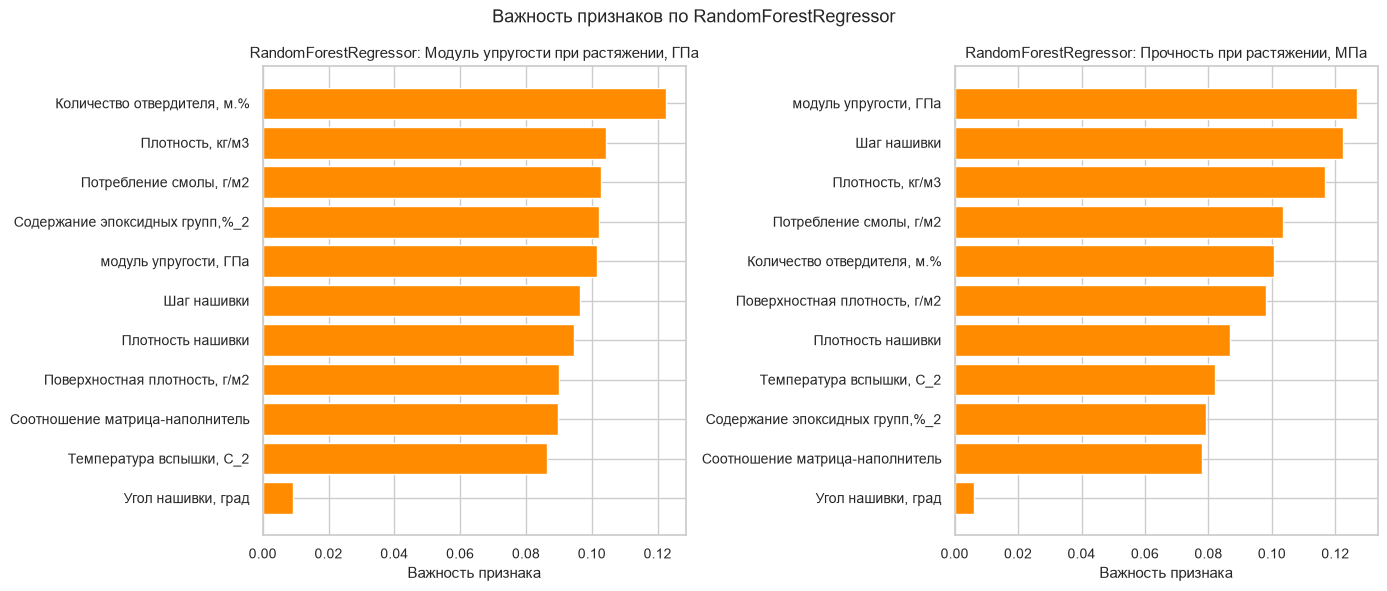

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, target_name in zip(axes, TARGETS):
    rf_grid = fitted_models[target_name]["RandomForestRegressor"]
    rf_model = rf_grid.best_estimator_.named_steps["model"]
    importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
    importances = importances.sort_values(ascending=True)

    ax.barh(importances.index, importances.values, color="darkorange")
    ax.set_xlabel("Важность признака")
    ax.set_title(f"RandomForestRegressor: {TARGET_LABELS[target_name]}", fontsize=11)

fig.suptitle("Важность признаков по RandomForestRegressor", fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "feature_importance_rf.png"), dpi=300, bbox_inches="tight")
plt.show()


## 7. Итоговый выбор модели по каждому объекту

Ниже — честная сводка по каждому целевому показателю: лучшая модель, её
метрики и сравнение с `DummyRegressor`. Если R² низкий или отрицательный,
это отражено без приукрашивания.

In [13]:
for target_name in TARGETS:
    table = metrics_tables[target_name]
    dummy_row = table.loc[table["Модель"] == "DummyRegressor"].iloc[0]
    best_name = best_model_names[target_name]
    best_row = table.loc[table["Модель"] == best_name].iloc[0]

    print(f"=== {TARGET_LABELS[target_name]} ===")
    print(f"DummyRegressor:  R2_test={dummy_row['R2_test']:.4f}, RMSE_test={dummy_row['RMSE_test']:.4f}")
    print(f"Лучшая модель:   {best_name}")
    print(f"                 R2_test={best_row['R2_test']:.4f}, RMSE_test={best_row['RMSE_test']:.4f}")
    improvement = best_row["R2_test"] - dummy_row["R2_test"]
    print(f"Прирост R2 относительно DummyRegressor: {improvement:+.4f}")
    print()


=== Модуль упругости при растяжении, ГПа ===
DummyRegressor:  R2_test=-0.0059, RMSE_test=2.9607
Лучшая модель:   SVR
                 R2_test=0.0016, RMSE_test=2.9496
Прирост R2 относительно DummyRegressor: +0.0075

=== Прочность при растяжении, МПа ===
DummyRegressor:  R2_test=-0.0351, RMSE_test=459.6448
Лучшая модель:   Ridge
                 R2_test=-0.0287, RMSE_test=458.2153
Прирост R2 относительно DummyRegressor: +0.0064



**Интерпретация (заполняется по фактическим результатам выше):**

- Если R² лучшей модели заметно выше нуля и выше R² `DummyRegressor` —
  модель улавливает содержательную зависимость между технологическими
  параметрами и целевым показателем, и её можно использовать как базовую
  прогнозную модель, понимая ограничения выборки.
- Если R² лучшей модели близок к нулю или ниже R² `DummyRegressor` —
  это означает, что имеющиеся 11 признаков **слабо объясняют** дисперсию
  целевого показателя на данной выборке (что согласуется с очень слабыми
  корреляциями, обнаруженными в Блоке 1 EDA — максимальный коэффициент
  корреляции между признаками не превышал ~0.11 по модулю). В этом случае
  честный вывод — предсказательная способность моделей на этих данных
  ограничена, и для практического применения потребовались бы
  дополнительные признаки или больше данных. Выбор "лучшей" модели в этом
  случае — это выбор наименее плохой альтернативы, а не модели с высокой
  прогностической ценностью.

## 8. Сохранение лучших пайплайнов

Сохраняем полные `Pipeline` (скейлер + лучшая модель с подобранными
гиперпараметрами) для обоих объектов прогнозирования в `app/models/` с
помощью `joblib`, чтобы их можно было использовать в приложении без
повторного обучения.

In [14]:
MODEL_FILENAMES = {
    "modulus": "best_model_modulus.joblib",
    "strength": "best_model_strength.joblib",
}

for target_name in TARGETS:
    best_name = best_model_names[target_name]
    best_pipeline = fitted_models[target_name][best_name].best_estimator_
    path = os.path.join(MODELS_DIR, MODEL_FILENAMES[target_name])
    joblib.dump(best_pipeline, path)
    print(f"Сохранён пайплайн для «{TARGET_LABELS[target_name]}»: {best_name} -> {path}")


Сохранён пайплайн для «Модуль упругости при растяжении, ГПа»: SVR -> ../app/models\best_model_modulus.joblib
Сохранён пайплайн для «Прочность при растяжении, МПа»: Ridge -> ../app/models\best_model_strength.joblib


## Выводы

- Для каждого из двух целевых показателей построен и обучен отдельный набор
  из 9 моделей (включая `DummyRegressor` в качестве базовой линии), с
  подбором гиперпараметров через `GridSearchCV(cv=10)`.
- Нормализация признаков выполнена внутри `Pipeline`, что исключает утечку
  данных между обучающей и тестовой выборками.
- Метрики MAE, MSE, RMSE и R² на train/test сохранены в
  `figures/metrics_modulus.csv` и `figures/metrics_strength.csv`.
- Графики сравнения моделей, прогноз-vs-факт и важность признаков сохранены
  в папке `figures/`.
- Лучшие пайплайны сохранены в `app/models/` для использования в
  приложении (Блок 3 ВКР).